# Mean-Variance Optimization

Welcome to Workshop 4.3! In our previous workshop, we learned how to protect our strategy using position sizing rules, volatility targeting, and hard concentration caps.

Now we take our next major step into mathematical asset allocation: **Modern Portfolio Theory** (MPT), pioneered by Nobel laureate Harry Markowitz in 1952.

Markowitz introduced a transformative insight: an investor should never judge a stock in isolation. Instead, what matters is how each asset interacts with the rest of the portfolio. By combining assets that do not move in perfect lockstep, we can reduce overall portfolio risk without sacrificing expected returns.

This mathematical framework is called **Mean-Variance Optimization**. It seeks the highest possible expected return (mean) for a given level of risk (variance).

In this workshop, we will compute expected returns and asset covariances. Then we will simulate thousands of portfolios to map out the legendary **Efficient Frontier** and locate the Maximum Sharpe and Minimum Variance portfolios.

> **Key Takeaway**: Diversification is the only free lunch in finance. By combining imperfectly correlated assets, we achieve a smoother ride than any single holding can deliver alone.

## Preliminary Step: Defining UniverseManager

We define our `UniverseManager` architecture to load cached Parquet files and compute daily returns.

Let's run this setup cell now.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

class UniverseManager:
    def __init__(self, tickers, start="2023-01-01", end="2024-01-01", cache_dir="data_cache"):
        self.tickers = tickers
        self.start = start
        self.end = end
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)

    def load_ticker(self, ticker):
        file_path = self.cache_dir / f"{ticker}.parquet"
        if file_path.exists():
            return pd.read_parquet(file_path)
        import yfinance as yf
        df = yf.download(ticker, start=self.start, end=self.end, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df.index = df.index.tz_localize(None)
        df.to_parquet(file_path)
        return df

    def build(self):
        dfs = []
        failed = []
        for ticker in self.tickers:
            try:
                t_df = self.load_ticker(ticker).copy()
                t_df["Ticker"] = ticker
                dfs.append(t_df)
            except Exception:
                failed.append(ticker)
        combined = pd.concat(dfs)
        combined = combined.reset_index().rename(columns={"index": "Date"})
        if "Date" not in combined.columns and "index" in combined.columns:
            combined = combined.rename(columns={"index": "Date"})
        universe = combined.set_index(["Date", "Ticker"]).sort_index()
        universe["Return_1d"] = universe.groupby(level="Ticker")["Close"].pct_change()
        return universe, failed

# Let's confirm UniverseManager is ready:
print("UniverseManager configured successfully.")

UniverseManager configured successfully.

## Topic 1: Loading Historical Returns

We begin by loading seven mega-cap leaders for 2023:
- Tech giants: `AAPL`, `MSFT`, `GOOGL`, `AMZN`, `NVDA`, `META`, `TSLA`.

To perform portfolio-level matrix algebra, we reshape our return series from long format into wide format using `.unstack(level='Ticker')`. In this wide matrix, each row represents a trading day and each column represents a stock.

Let's load the data and inspect our returns matrix.

In [2]:
# Load universe and returns:
universe, _ = UniverseManager(["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA"], "2023-01-01", "2024-01-01").build()
returns_wide = universe["Return_1d"].unstack(level="Ticker").dropna()

# Let's inspect the wide returns matrix:
print(f"Historical returns matrix shape: {returns_wide.shape}")
print(f"Trading Days: {len(returns_wide)}")
print("\nFirst 5 days of daily returns:")
print(returns_wide.head())

Historical returns matrix shape: (249, 7)
Trading Days: 249

First 5 days of daily returns:
Ticker          AAPL      AMZN     GOOGL  ...      MSFT      NVDA      TSLA
Date                                      ...                              
2023-01-04  0.010314 -0.007924 -0.011670  ... -0.043743  0.030318  0.051249
2023-01-05 -0.010605 -0.023726 -0.021344  ... -0.029638 -0.032816 -0.029039
2023-01-06  0.036794  0.035611  0.013225  ...  0.011785  0.041640  0.024651
2023-01-09  0.004089  0.014870  0.007786  ...  0.009737  0.051753  0.059349
2023-01-10  0.004457  0.028732  0.004545  ...  0.007617  0.017981 -0.007681

[5 rows x 7 columns]

## Topic 2: Calculating Expected Returns and Covariance

In Mean-Variance Optimization, the portfolio return and volatility depend on two core inputs:
- **Expected Returns Vector** $\mathbf{\mu}$: The annualized mean return for each asset.
- **Covariance Matrix** $\mathbf{\Sigma}$: The annualized covariance between every pair of assets.

We annualize daily returns and covariances by multiplying by 252 (the standard number of trading days in a year).

The diagonal of the covariance matrix gives each asset's individual variance. The off-diagonal entries capture how stocks move together.

Let's compute both inputs and examine them.

In [3]:
expected_returns = returns_wide.mean() * 252  # annualized
covariance_matrix = returns_wide.cov() * 252  # annualized

# Let's inspect our expected returns:
print("Expected Annualized Returns:")
for ticker, ret in expected_returns.items():
    print(f"  {ticker:5s}: {ret:7.2%}")

# Let's check the annualized individual volatilities:
print("\nAnnualized Asset Volatilities (Square Root of Diagonal):")
volatilities = np.sqrt(np.diag(covariance_matrix))
for ticker, vol in zip(expected_returns.index, volatilities):
    print(f"  {ticker:5s}: {vol:7.2%}")

print("\nCovariance Matrix (Annually Scaled):")
print(covariance_matrix.round(4))

Expected Annualized Returns:
  AAPL :  46.24%
  AMZN :  63.29%
  GOOGL:  50.14%
  META : 113.23%
  MSFT :  49.69%
  NVDA : 137.13%
  TSLA :  98.10%

Annualized Asset Volatilities (Square Root of Diagonal):
  AAPL :  19.95%
  AMZN :  33.03%
  GOOGL:  30.40%
  META :  39.83%
  MSFT :  25.12%
  NVDA :  48.46%
  TSLA :  52.65%

Covariance Matrix (Annually Scaled):
Ticker    AAPL    AMZN   GOOGL    META    MSFT    NVDA    TSLA
Ticker                                                        
AAPL    0.0398  0.0291  0.0320  0.0430  0.0275  0.0430  0.0467
AMZN    0.0291  0.1091  0.0603  0.0763  0.0478  0.0609  0.0649
GOOGL   0.0320  0.0603  0.0924  0.0736  0.0389  0.0598  0.0541
META    0.0430  0.0763  0.0736  0.1586  0.0533  0.0793  0.0794
MSFT    0.0275  0.0478  0.0389  0.0533  0.0631  0.0654  0.0420
NVDA    0.0430  0.0609  0.0598  0.0793  0.0654  0.2348  0.1042
TSLA    0.0467  0.0649  0.0541  0.0794  0.0420  0.1042  0.2772

## Topic 3: Simulating Random Portfolios

Rather than jumping straight into complex mathematical solvers, we can build strong intuition by simulating 5,000 random portfolios.

Think of Monte Carlo simulation as casting a wide net across the investment landscape:
- We generate random asset weights using `np.random.random()`.
- We divide each weight vector by its sum so allocations total 100%.
- We calculate portfolio return as $\mu_p = \mathbf{w}^T \mathbf{\mu}$.
- We calculate portfolio volatility as $\sigma_p = \sqrt{\mathbf{w}^T \mathbf{\Sigma} \mathbf{w}}$.
- We record the Sharpe ratio: $\frac{\mu_p}{\sigma_p}$.

Let's run this simulation and inspect the first few results.

In [4]:
import numpy as np

# Set random seed for reproducibility:
np.random.seed(42)

# Simulate random portfolios across the risk-return spectrum:
def random_portfolios(returns, cov_matrix, num_portfolios=5000):
    results = []
    for _ in range(num_portfolios):
        weights = np.random.random(len(returns))
        weights = weights / weights.sum()
        port_return = np.dot(weights, returns)
        port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe = port_return / port_risk
        results.append([port_return, port_risk, sharpe] + list(weights))
    return pd.DataFrame(results, columns=["Return", "Risk", "Sharpe"] + list(returns.index))

# Run our portfolio simulation:
simulated_portfolios = random_portfolios(expected_returns, covariance_matrix, num_portfolios=5000)

# Let's inspect the generated portfolios:
print(f"Generated {len(simulated_portfolios)} random portfolios.")
print("\nFirst 5 simulated portfolios:")
print(simulated_portfolios[["Return", "Risk", "Sharpe", "AAPL", "MSFT", "NVDA"]].head())

Generated 5000 random portfolios.

First 5 simulated portfolios:
     Return      Risk    Sharpe      AAPL      MSFT      NVDA
0  0.716518  0.261157  2.743623  0.123774  0.051559  0.051551
1  0.710359  0.242299  2.931744  0.205711  0.230347  0.197700
2  0.854428  0.283819  3.010467  0.071889  0.170780  0.115144
3  0.769256  0.263636  2.917873  0.050667  0.285191  0.072525
4  0.907360  0.306581  2.959609  0.174419  0.019153  0.279371

## Topic 4: The Maximum Sharpe Ratio Portfolio

Among all simulated portfolios, one point stands out: the portfolio with the highest Sharpe ratio.

This optimal combination is known as the **Tangency Portfolio**. It offers the highest reward per unit of total risk.

Let's locate the portfolio with the peak Sharpe ratio and inspect its asset allocation.

In [5]:
def max_sharpe_portfolio(returns, cov_matrix):
    # Select the simulated portfolio with the highest Sharpe ratio:
    results = random_portfolios(returns, cov_matrix)
    best = results.loc[results["Sharpe"].idxmax()]
    return best

# Find optimal Max Sharpe portfolio:
best_sharpe = max_sharpe_portfolio(expected_returns, covariance_matrix)

# Let's inspect the optimal portfolio characteristics:
print("Maximum Sharpe Ratio Portfolio:")
print(f"  Expected Return:     {best_sharpe['Return']:7.2%}")
print(f"  Annualized Risk:     {best_sharpe['Risk']:7.2%}")
print(f"  Sharpe Ratio:        {best_sharpe['Sharpe']:7.3f}")
print("\nOptimal Portfolio Weights:")
for ticker in expected_returns.index:
    print(f"  {ticker:5s}: {best_sharpe[ticker]:7.2%}")

Maximum Sharpe Ratio Portfolio:
  Expected Return:      93.57%
  Annualized Risk:      27.81%
  Sharpe Ratio:          3.364

Optimal Portfolio Weights:
  AAPL :  36.66%
  AMZN :   1.09%
  GOOGL:   0.74%
  META :  23.98%
  MSFT :   1.16%
  NVDA :  31.14%
  TSLA :   5.23%

## Topic 5: The Minimum Variance Portfolio

At the far left edge of our simulated cloud sits the **Minimum Variance Portfolio**.

This portfolio does not try to maximize returns. Instead, it seeks the single lowest level of overall risk achievable by blending our assets. It is the portfolio of choice for conservative institutions focused on capital preservation.

Let's find the portfolio that minimizes risk and inspect its weights.

In [6]:
def min_variance_portfolio(cov_matrix):
    # Locate the portfolio with the lowest overall risk:
    results = random_portfolios(expected_returns, covariance_matrix)
    best = results.loc[results["Risk"].idxmin()]
    return best

# Find Minimum Variance portfolio:
best_min_var = min_variance_portfolio(covariance_matrix)

# Let's inspect the minimum risk portfolio characteristics:
print("Minimum Variance Portfolio:")
print(f"  Expected Return:     {best_min_var['Return']:7.2%}")
print(f"  Annualized Risk:     {best_min_var['Risk']:7.2%}")
print(f"  Sharpe Ratio:        {best_min_var['Sharpe']:7.3f}")
print("\nMinimum Variance Portfolio Weights:")
for ticker in expected_returns.index:
    print(f"  {ticker:5s}: {best_min_var[ticker]:7.2%}")

Minimum Variance Portfolio:
  Expected Return:      50.06%
  Annualized Risk:      20.91%
  Sharpe Ratio:          2.394

Minimum Variance Portfolio Weights:
  AAPL :  32.26%
  AMZN :   1.07%
  GOOGL:  30.73%
  META :   0.90%
  MSFT :  34.06%
  NVDA :   0.39%
  TSLA :   0.59%

## Topic 6: Comparing Different Portfolios

Let's compare three distinct allocation strategies side by side:
- **Equal Weight**: Allocating $1/N = 14.29\%$ across all seven stocks.
- **Maximum Sharpe**: The optimal risk-adjusted portfolio.
- **Minimum Variance**: The lowest-volatility portfolio.

Notice how the weights differ dramatically. Equal weighting blindly spreads capital across everything, while optimization concentrates capital into assets with superior risk-return traits.

Let's view the comparison table.

In [7]:
# We calculate metrics for the equal weight baseline:
num_assets = len(expected_returns)
eq_weights = np.ones(num_assets) / num_assets
eq_return = np.dot(eq_weights, expected_returns)
eq_risk = np.sqrt(np.dot(eq_weights.T, np.dot(covariance_matrix, eq_weights)))
eq_sharpe = eq_return / eq_risk

# We build a comparative summary table:
comparison_df = pd.DataFrame({
    "Equal Weight": [eq_return, eq_risk, eq_sharpe],
    "Max Sharpe": [best_sharpe["Return"], best_sharpe["Risk"], best_sharpe["Sharpe"]],
    "Minimum Variance": [best_min_var["Return"], best_min_var["Risk"], best_min_var["Sharpe"]]
}, index=["Expected Return", "Annualized Risk", "Sharpe Ratio"])

# Let's inspect the comparative performance metrics:
print("Comparative Performance Table:")
print(comparison_df.round(4))

# Weight comparison table:
weights_comparison = pd.DataFrame({
    "Equal Weight": eq_weights,
    "Max Sharpe": [best_sharpe[t] for t in expected_returns.index],
    "Minimum Variance": [best_min_var[t] for t in expected_returns.index]
}, index=expected_returns.index)

print("\nPortfolio Asset Allocations:")
print((weights_comparison * 100).round(2).astype(str) + "%")

Comparative Performance Table:
                 Equal Weight  Max Sharpe  Minimum Variance
Expected Return        0.7969      0.9357            0.5006
Annualized Risk        0.2610      0.2781            0.2091
Sharpe Ratio           3.0532      3.3641            2.3943

Portfolio Asset Allocations:
       Equal Weight Max Sharpe Minimum Variance
Ticker                                         
AAPL         14.29%     36.66%           32.26%
AMZN         14.29%      1.09%            1.07%
GOOGL        14.29%      0.74%           30.73%
META         14.29%     23.98%             0.9%
MSFT         14.29%      1.16%           34.06%
NVDA         14.29%     31.14%            0.39%
TSLA         14.29%      5.23%            0.59%

## Topic 7: The Efficient Frontier Visualization

Now we arrive at one of the most famous charts in financial economics: the **Efficient Frontier**.

The upper boundary of the simulated cloud represents portfolios that deliver maximum return for each level of risk. Any portfolio sitting below the frontier is sub-optimal because you could achieve higher returns for the same volatility.

Let's plot our 5,000 simulated portfolios, coloring each point by its Sharpe ratio and highlighting our key benchmark portfolios.

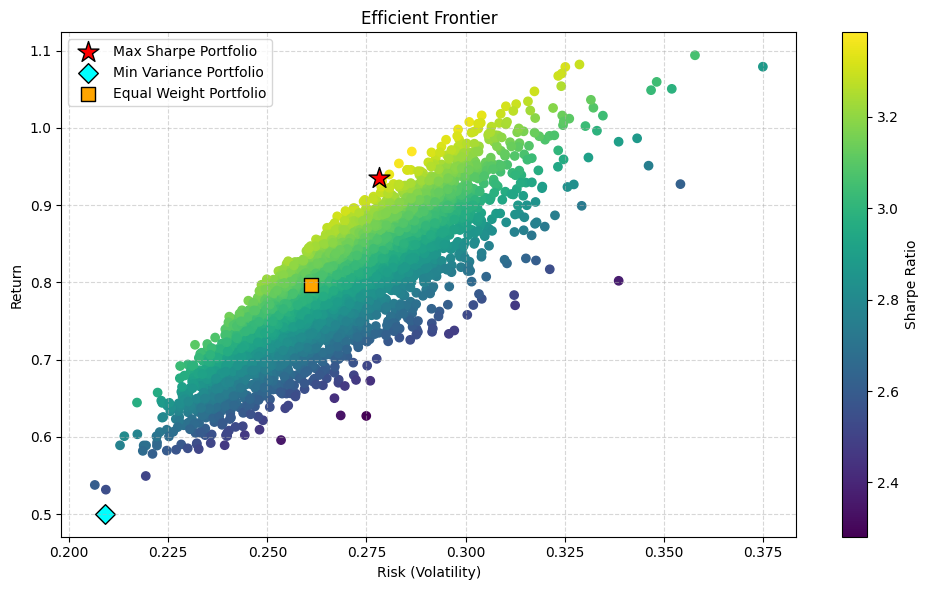

In [8]:
import matplotlib.pyplot as plt

results = random_portfolios(expected_returns, covariance_matrix)
plt.figure(figsize=(10, 6))
plt.scatter(results["Risk"], results["Return"], c=results["Sharpe"], cmap="viridis")
plt.colorbar(label="Sharpe Ratio")

# Highlight key benchmark portfolios:
plt.scatter(best_sharpe["Risk"], best_sharpe["Return"], color="red", marker="*", s=250, label="Max Sharpe Portfolio", edgecolors="black")
plt.scatter(best_min_var["Risk"], best_min_var["Return"], color="cyan", marker="D", s=100, label="Min Variance Portfolio", edgecolors="black")
plt.scatter(eq_risk, eq_return, color="orange", marker="s", s=100, label="Equal Weight Portfolio", edgecolors="black")

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.grid(True, linestyle="dashed", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

---

## Practice Time

Now it is your turn to experiment with the Efficient Frontier. Complete the three challenges below.

---

### Challenge 1: Expanding the Frontier with Non-Tech Assets
Expand the universe from seven stocks to nine by adding `JPM` (JPMorgan Chase) and `XOM` (ExxonMobil) from cache. Run 5,000 simulations and compare the new minimum risk level against our 7-stock baseline. Does adding non-tech stocks reduce portfolio risk?

---

### Challenge 2: Constrained Optimization with a Risk Budget
Using the 9-stock simulation from Challenge 1, filter for portfolios with annualized risk less than or equal to 20% (`Risk <= 0.20`). Find the portfolio that maximizes return within this risk budget and report its expected return and top holdings.

---

### Challenge 3: Diagnosing Optimization Pitfalls
Look closely at the weights of the unconstrained Maximum Sharpe portfolio. Why does it concentrate so heavily in top historical winners like Nvidia? What danger does this create for live trading?

In [9]:
# Challenge 1: Add JPM and XOM and recompute efficient frontier
# Write your code below this line:



In [10]:
# Challenge 2: Find the portfolio that maximizes return for risk <= 0.20
# Write your code below this line:



In [11]:
# Challenge 3: Explain concentration in Maximum Sharpe portfolios
# Write your answer below this line:



---

## Solutions

Review the reference implementations below whenever you are ready to compare your results.

### Solution for Challenge 1

In [12]:
# Solution for Challenge 1:
universe_9, _ = UniverseManager(
    ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "XOM"],
    "2023-01-01",
    "2024-01-01"
).build()

returns_9 = universe_9["Return_1d"].unstack(level="Ticker").dropna()
exp_ret_9 = returns_9.mean() * 252
cov_mat_9 = returns_9.cov() * 252

np.random.seed(42)
sim_9 = random_portfolios(exp_ret_9, cov_mat_9, num_portfolios=5000)
min_var_9 = sim_9.loc[sim_9["Risk"].idxmin()]

# Let's inspect the risk reduction from adding non-tech assets:
print(f"7-Stock Minimum Risk: {best_min_var['Risk']:.2%}")
print(f"9-Stock Minimum Risk: {min_var_9['Risk']:.2%}")
print(f"Reduction in Risk:    {(best_min_var['Risk'] - min_var_9['Risk']):.2%}")

7-Stock Minimum Risk: 20.91%
9-Stock Minimum Risk: 15.63%
Reduction in Risk:    5.28%

In [13]:
# Solution for Challenge 2:
sub_20 = sim_9[sim_9["Risk"] <= 0.20]
best_at_20 = sub_20.loc[sub_20["Return"].idxmax()]

# Let's inspect the constrained portfolio:
print(f"Optimal Portfolio with Risk <= 20%:")
print(f"  Expected Return: {best_at_20['Return']:.2%}")
print(f"  Realized Risk:   {best_at_20['Risk']:.2%}")
print(f"  Sharpe Ratio:    {best_at_20['Sharpe']:.3f}")
print("\nTop 4 Holdings in this Portfolio:")
weights_20 = best_at_20[exp_ret_9.index].sort_values(ascending=False).head(4)
for t, w in weights_20.items():
    print(f"  {t:5s}: {w:6.2%}")

Optimal Portfolio with Risk <= 20%:
  Expected Return: 64.34%
  Realized Risk:   19.94%
  Sharpe Ratio:    3.227

Top 4 Holdings in this Portfolio:
  NVDA : 17.30%
  AAPL : 17.00%
  XOM  : 16.69%
  META : 13.62%

In [14]:
# Solution for Challenge 3:
print("Exercise 3 Summary:")
print("1. Maximum Sharpe portfolios aggressively overweight historical top performers.")
print("2. In 2023, NVDA (+137%) and META (+113%) dominated the Sharpe ratio.")
print("3. Unconstrained optimization suffers from 'error maximization'.")
print("4. Professional quants enforce position limits (e.g. max 20% per asset) to safeguard against future regime shifts.")

Exercise 3 Summary:
1. Maximum Sharpe portfolios aggressively overweight historical top performers.
2. In 2023, NVDA (+137%) and META (+113%) dominated the Sharpe ratio.
3. Unconstrained optimization suffers from 'error maximization'.
4. Professional quants enforce position limits (e.g. max 20% per asset) to safeguard against future regime shifts.